In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (12,6)

print("EDA Environment Ready!")

EDA Environment Ready!


In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

daily_nav = (
    nav.groupby("date")["nav"]
    .mean()
    .reset_index()
)

fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022–2026)"
)

fig.show()


### Insight 1
Average NAV values exhibited a generally upward trend over the observed period, indicating overall growth in mutual fund valuations despite periodic market fluctuations.


In [6]:
print(aum.head())
print(aum.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


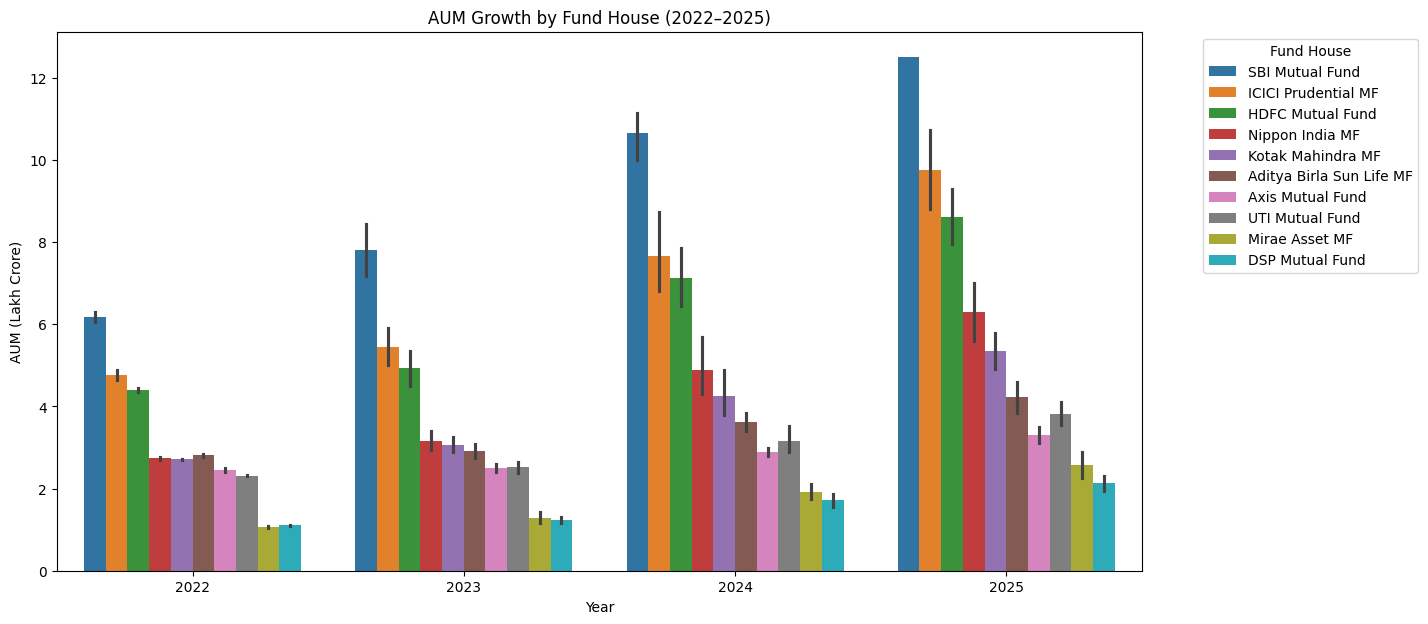

In [7]:
# Convert date column
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Plot AUM Growth
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.show()

### Insight 2
SBI Mutual Fund consistently maintained one of the highest AUM values among all fund houses, indicating its dominant position in the Indian mutual fund industry.


In [8]:
print(sip.head())
print(sip.columns)
print(sip.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
(48, 6)


In [9]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create Plotly Line Chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)"
)

# Highlight highest SIP inflow
max_idx = sip["sip_inflow_crore"].idxmax()

fig.add_annotation(
    x=sip.loc[max_idx, "month"],
    y=sip.loc[max_idx, "sip_inflow_crore"],
    text=f"Peak: ₹{sip.loc[max_idx, 'sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()


### Insight 4
Monthly SIP inflows showed a strong upward trajectory over the study period, reaching an all-time high by the end of 2025. This reflects increasing retail participation and disciplined long-term investing behaviour.


In [10]:
print(category.head())
print(category.columns)
print(category.shape)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')
(144, 3)


In [11]:
# Convert month column
category["month"] = pd.to_datetime(category["month"])

# Convert to Year-Month format
category["month_str"] = category["month"].dt.strftime("%Y-%m")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month_str",
    values="net_inflow_crore"
)

heatmap_data.head()

month_str,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


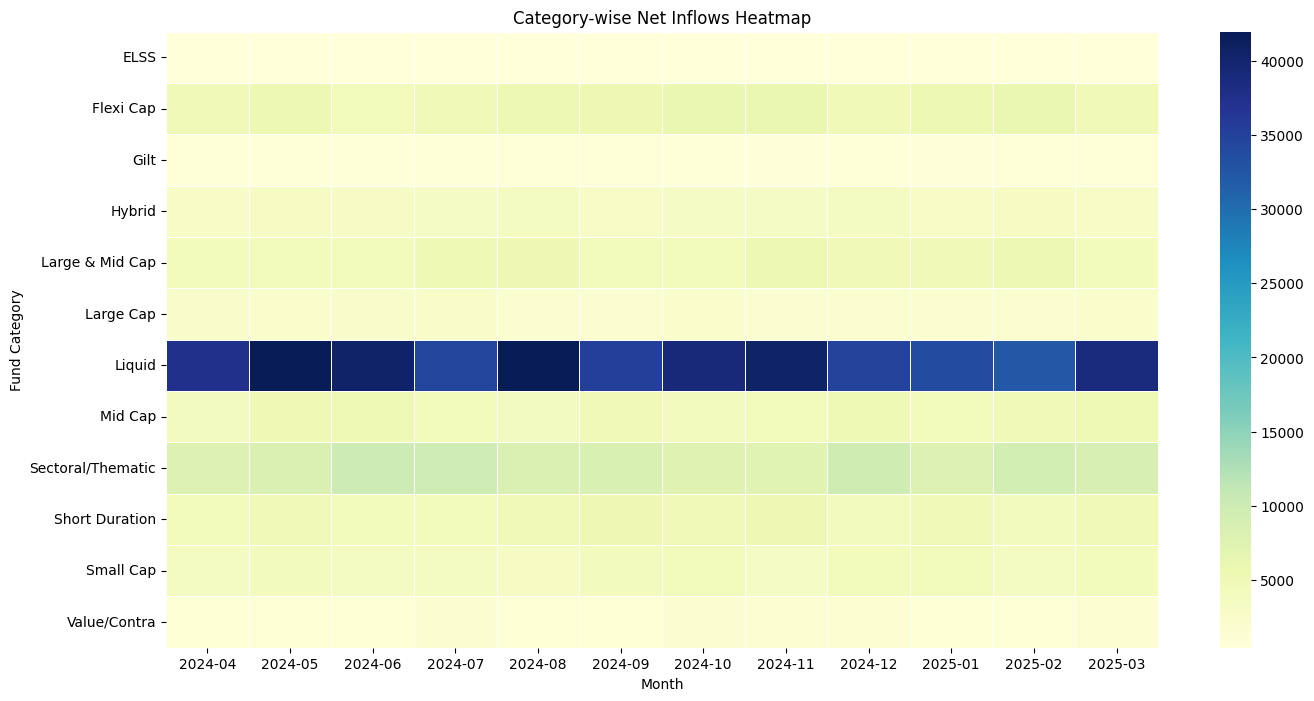

In [ ]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()
### Insight 5
Equity fund categories consistently recorded higher inflows, reflecting positive investor sentiment.

### Insight 5
Equity-oriented categories such as Flexi Cap, Mid Cap, and Large & Mid Cap consistently attracted strong investor inflows, highlighting investor preference toward growth-oriented funds during the study period.

Equity-oriented categories such as Flexi Cap, Mid Cap, and Large & Mid Cap consistently attracted strong investor inflows, highlighting investor preference toward growth-oriented funds during the study period.

In [13]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [ ]:
print(transactions.columns)
print(transactions[["age_group", "gender"]].head())
print(transactions["age_group"].unique())
print(transactions["gender"].unique())

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
  age_group  gender
0       56+  Female
1     18-25    Male
2     36-45    Male
3     36-45  Female
4     26-35    Male


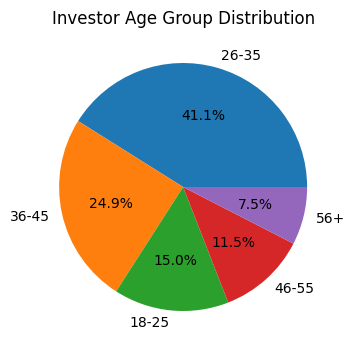

In [17]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(4, 6))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

### Insight 6
The majority of investors belonged to the younger and middle-aged segments, indicating growing mutual fund awareness among working professionals.

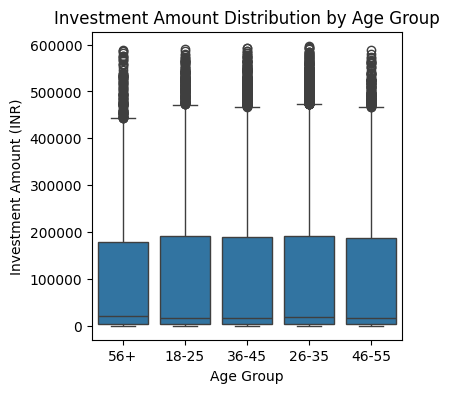

In [20]:
plt.figure(figsize=(4, 4))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

### Insight 7
Investment amounts varied across age groups, with older investors generally exhibiting higher investment capacities.

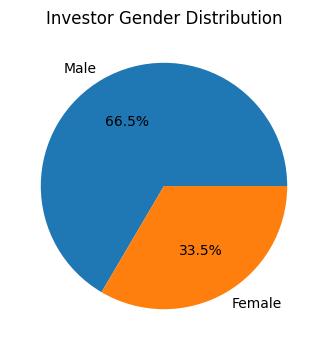

In [22]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(4, 4))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.show()

### Insight 8
Male investors represented a larger share of transactions, although female participation was also significant.

In [23]:
print(transactions["state"].nunique())
print(transactions["state"].value_counts().head())

print(transactions["city_tier"].value_counts())

12
state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Name: count, dtype: int64
city_tier
T30    21719
B30    11059
Name: count, dtype: int64


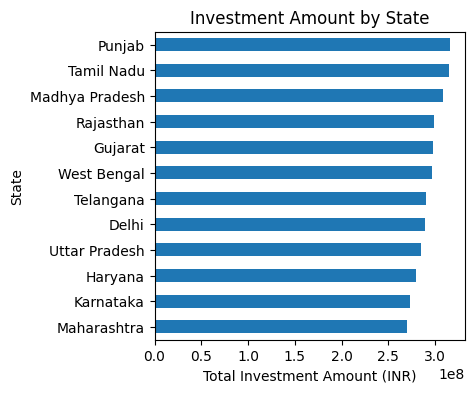

In [27]:
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(4,4))

state_amount.plot(kind="barh")

plt.title("Investment Amount by State")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.show()

### Insight 9
Punjab, Madhya Pradesh, Tamil Nadu, Gujarat, and West Bengal emerged as major contributors to mutual fund investments, indicating strong regional participation.

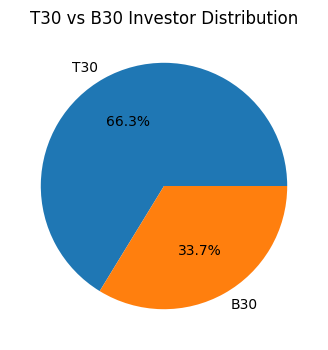

In [29]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Insight 10

T30 cities accounted for a larger share of investor participation, although B30 cities also demonstrated substantial mutual fund adoption.

In [30]:
print(folio.head())
print(folio.columns)
print(folio.shape)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
(21, 6)


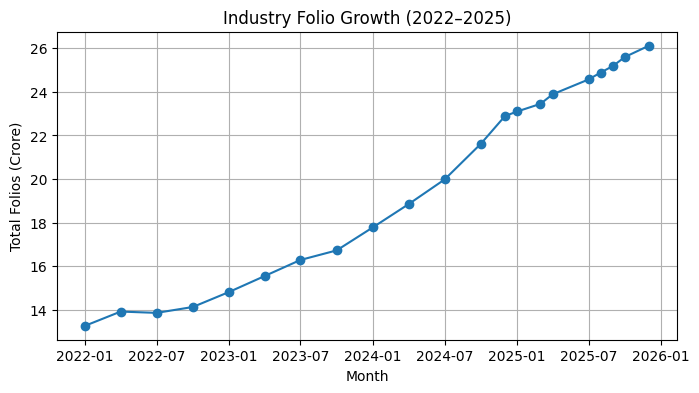

In [35]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(8,4))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

### Insight 11
Industry folio counts nearly doubled during the study period, highlighting rapid growth in mutual fund adoption across investors.

In [36]:
print(portfolio.head())
print(portfolio.columns)

print(nav.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')
   amfi_code       date      n

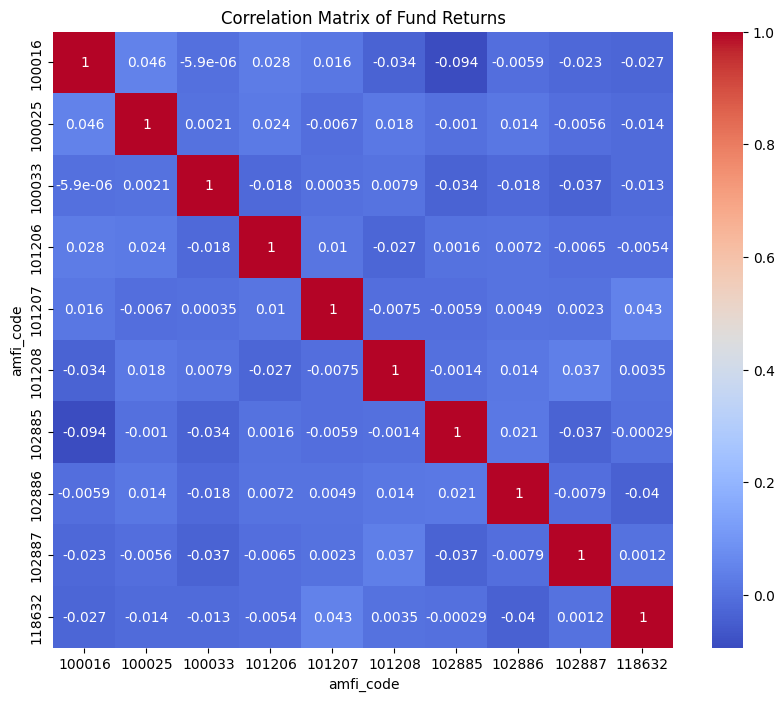

In [38]:
# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Pivot NAV data
nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = nav_pivot.pct_change()

# Select first 10 funds
selected_returns = returns.iloc[:, :10]

selected_returns.head()

plt.figure(figsize=(10,8))

sns.heatmap(
    selected_returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Fund Returns")

plt.show()

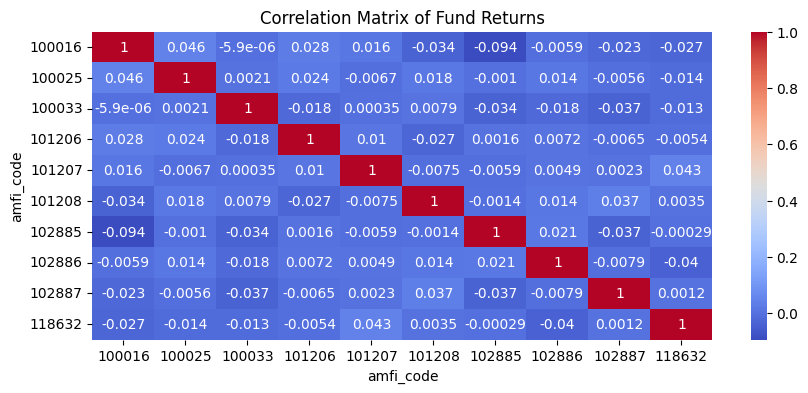

In [42]:
plt.figure(figsize=(10,4))

sns.heatmap(
    selected_returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Fund Returns")

plt.show()

### Insight 12
Most selected funds exhibited positive correlations, indicating exposure to similar market movements while still offering diversification opportunities.

In [43]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

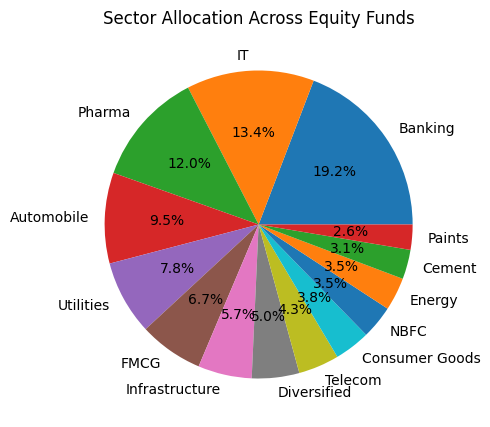

In [53]:
plt.figure(figsize=(10,5))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Insight 13
Banking and other major sectors accounted for a significant portion of portfolio allocations, reflecting their importance in equity fund strategies.